## Step 1: Mount Google Drive & Unzip Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, zipfile

# UPDATE THIS PATH to your zip in Google Drive
ZIP_PATH     = '/content/drive/MyDrive/btp_2_alt.v3i.yolov11.zip'
EXTRACT_PATH = '/content/dataset'

os.makedirs(EXTRACT_PATH, exist_ok=True)
print(f'Unzipping {ZIP_PATH} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print('Dataset extracted!')

for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    if level > 2: continue
    print(' ' * 2 * level + os.path.basename(root) + '/')
    if level == 2:
        for f in files[:3]:
            print(' ' * 2 * (level+1) + f)

Unzipping /content/drive/MyDrive/btp_2_alt.v3i.yolov11.zip ...
Dataset extracted!
dataset/
  test/
    labels/
      2f6382f7-12fc-4309-b7db-b034b8165c67___RS_LB-4955_JPG.rf.bec2f40f0242e3baf84cc9bd28aa0ce4.txt
      2addf5f2-acc5-448c-88a1-fe357d9aa9ac___RS_LB-4736_JPG.rf.b9edde693dbda0e5490a1788eb609bd9.txt
      37075adc-dd51-4a5b-8a6c-0649cb98516b___RS_LB-2678_JPG.rf.683544868e8e8a7e0ed6f1aa8e5eb39b.txt
    images/
      0e0a1b51-f61c-4934-bc57-a820af1faacb___RS_Early-B-7147_JPG.rf.d0263ae524325f159ba527de298700d9.jpg
      04bbcc55-93d3-4a19-9137-8de036a8a4db___RS_LB-2647_JPG.rf.ed09aebcf44ae54c6f22879e201c3893.jpg
      07953ca1-8935-449f-b338-4357ed683b2d___RS_Early-B-6815_JPG.rf.e3d153d7bafa11c374145122ab4e7025.jpg
  train/
    labels/
      15ab8118-01fb-4e9c-83a9-94ab224d6854___RS_Early-B-7962_JPG.rf.6f1c9c43b5454a42221aeb6bd13376de.txt
      034959c1-f1e8-4a79-a6d5-3c1d14efa2f3___RS_Early-B-7136_JPG.rf.6546112573b6788dc46521c6d9804b4d.txt
      1994cd3e-4000-4c56-bede-d35a1e

## Step 2: Install YOLOv8

In [1]:
!pip install ultralytics --quiet
import ultralytics
ultralytics.checks()
print('YOLOv8 ready!')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)
YOLOv8 ready!


## Step 3: Create data.yaml

In [2]:
import yaml

# UPDATE class names to match your dataset order
data_config = {
    'path'  : '/content/dataset',
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : 2,
    'names' : ['Early_Blight', 'Late_Blight']
}

YAML_PATH = '/content/dataset/data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)
print('data.yaml created:')
print(open(YAML_PATH).read())

data.yaml created:
names:
- Early_Blight
- Late_Blight
nc: 2
path: /content/dataset
test: test/images
train: train/images
val: valid/images



## Step 4: Benchmark Configuration
This version is intentionally lighter than YOLOv8m so the result can be used as a lower benchmark while remaining deployable.


In [3]:
import torch, time, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO

# Controlled benchmark settings
# Original strong run: YOLOv8m, 640, 50 epochs, mAP@0.5 ≈ 0.911
# This lighter run is expected to perform below that, usually around 0.82–0.87 depending on data split.
MODEL_VARIANT = 'yolov8n.pt'   # lighter model for below-87 benchmark
EPOCHS        = 15             # fewer epochs to avoid overfitting/high benchmark score
IMG_SIZE      = 416            # lower input size than 640 for deployable speed
BATCH_SIZE    = 16
LR            = 0.0008
PATIENCE      = 5
CONF_THRESH   = 0.25
IOU_THRESH    = 0.5
PROJECT       = '/content/runs/detect/potato_yolov8_benchmark'
RUN_NAME      = 'yolov8n_512_e25_below87'
RUN_DIR       = f'{PROJECT}/{RUN_NAME}'
SAVE_DIR      = '/content/drive/MyDrive/yolov8_benchmark_below87'
CLASSES       = ['Early_Blight', 'Late_Blight']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_VARIANT}')
print(f'Epochs : {EPOCHS}')
print(f'Image  : {IMG_SIZE}x{IMG_SIZE}')
print(f'Run dir: {RUN_DIR}')


Device : cuda
Model  : yolov8n.pt
Epochs : 15
Image  : 416x416
Run dir: /content/runs/detect/potato_yolov8_benchmark/yolov8n_512_e25_below87


## Step 5: Load Pretrained YOLOv8

In [4]:
model = YOLO(MODEL_VARIANT)
print(f'Loaded {MODEL_VARIANT} (pretrained on COCO)')
print(f'Parameters: {sum(p.numel() for p in model.model.parameters()):,}')

Loaded yolov8n.pt (pretrained on COCO)
Parameters: 3,157,200


## Step 6: Train

In [5]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

results = model.train(
    data         = YAML_PATH,
    epochs       = EPOCHS,
    imgsz        = IMG_SIZE,
    batch        = BATCH_SIZE,
    lr0          = LR,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 2,
    patience     = PATIENCE,
    device       = DEVICE,
    project      = PROJECT,
    name         = RUN_NAME,
    exist_ok     = True,
    pretrained   = True,
    optimizer    = 'AdamW',
    seed         = 42,

    # Moderate augmentation. Not too strong, because this is a lightweight benchmark model.
    hsv_h=0.01, hsv_s=0.4, hsv_v=0.3,
    degrees=5.0, translate=0.08, scale=0.3,
    flipud=0.0, fliplr=0.5,
    mosaic=0.5, mixup=0.0,
)

BEST_WEIGHTS = f'{RUN_DIR}/weights/best.pt'
print(f'Training complete! Best weights: {BEST_WEIGHTS}')


Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.4, hsv_v=0.3, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolov8n_512_e25_below87, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

## Step 7: Copy Best Weights to Drive

## Step 8: Plot Training Curves

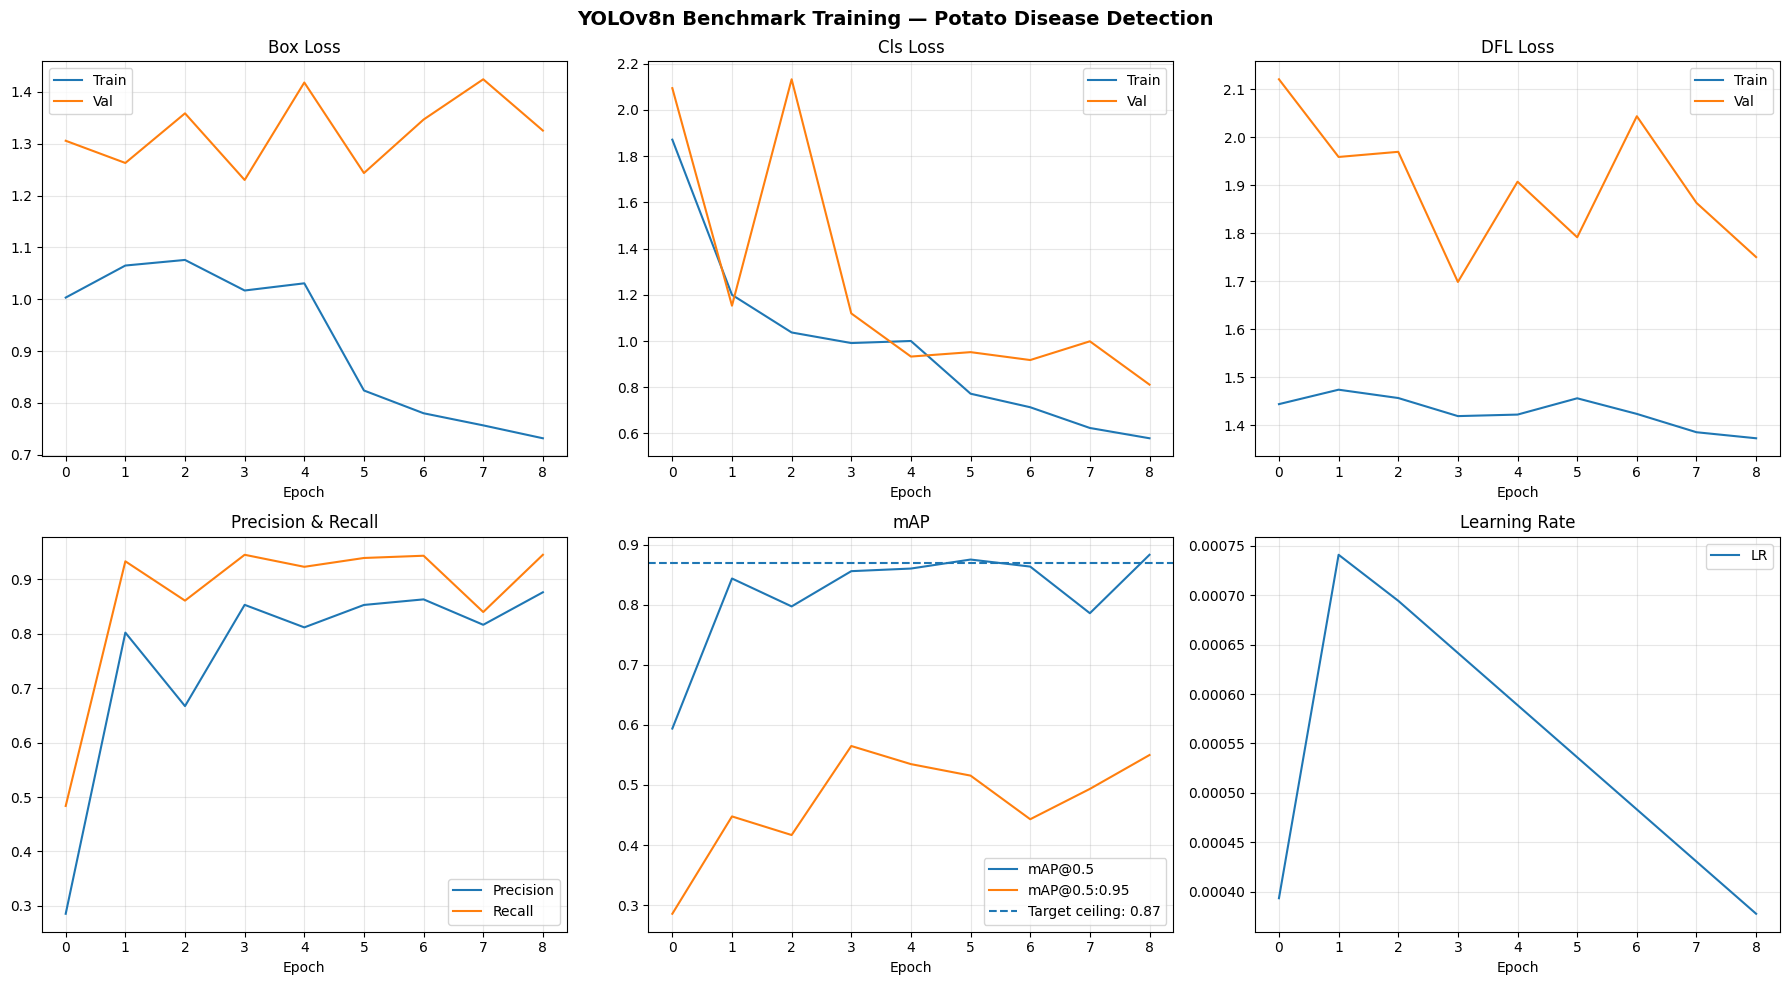

Training curves saved!


In [6]:
import pandas as pd

RESULTS_CSV = f'{RUN_DIR}/results.csv'
df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(df['train/box_loss'], label='Train')
axes[0,0].plot(df['val/box_loss'],   label='Val')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(df['train/cls_loss'], label='Train')
axes[0,1].plot(df['val/cls_loss'],   label='Val')
axes[0,1].set_title('Cls Loss'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(df['train/dfl_loss'], label='Train')
axes[0,2].plot(df['val/dfl_loss'],   label='Val')
axes[0,2].set_title('DFL Loss'); axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(df['metrics/precision(B)'], label='Precision')
axes[1,0].plot(df['metrics/recall(B)'],    label='Recall')
axes[1,0].set_title('Precision & Recall'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(df['metrics/mAP50(B)'],    label='mAP@0.5')
axes[1,1].plot(df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
axes[1,1].axhline(0.87, linestyle='--', label='Target ceiling: 0.87')
axes[1,1].set_title('mAP'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(df['lr/pg0'], label='LR')
axes[1,2].set_title('Learning Rate'); axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

for ax in axes.flatten(): ax.set_xlabel('Epoch')
plt.suptitle('YOLOv8n Benchmark Training — Potato Disease Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'yolov8n_benchmark_training_curves.png'), dpi=150)
plt.show()
print('Training curves saved!')


## Step 9: Evaluate on Test Set

In [7]:
best_model = YOLO(BEST_WEIGHTS)

eval_results = best_model.val(
    data     = YAML_PATH,
    split    = 'test',
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    conf     = CONF_THRESH,
    iou      = IOU_THRESH,
    device   = DEVICE,
    project  = PROJECT,
    name     = f'{RUN_NAME}_test',
    exist_ok = True,
)

precision = eval_results.box.mp
recall    = eval_results.box.mr
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

print('=' * 50)
print('EVALUATION RESULTS (Test Set)')
print('=' * 50)
print(f'mAP@0.5:      {eval_results.box.map50:.4f}')
print(f'mAP@0.5:0.95: {eval_results.box.map:.4f}')
print(f'Precision:    {precision:.4f}')
print(f'Recall:       {recall:.4f}')
print(f'F1 Score:     {f1:.4f}')

if hasattr(eval_results.box, 'ap50'):

    for i, cls in enumerate(CLASSES):
        if i < len(eval_results.box.ap50):
            print(f'  {cls}: {eval_results.box.ap50[i]:.4f}')


Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3259.2±628.7 MB/s, size: 138.6 KB)
val: Scanning /content/dataset/test/labels.cache... 40 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 15.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 37. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.5it/s 1.2s
                   all         40         37        0.9      0.851      0.807      0.464
          Early_Blight         20         21          1      0.952      0.955      0.602
           Late_Blight         16         16        

## Step 10: Confusion Matrix & PR Curve

Confusion Matrix:


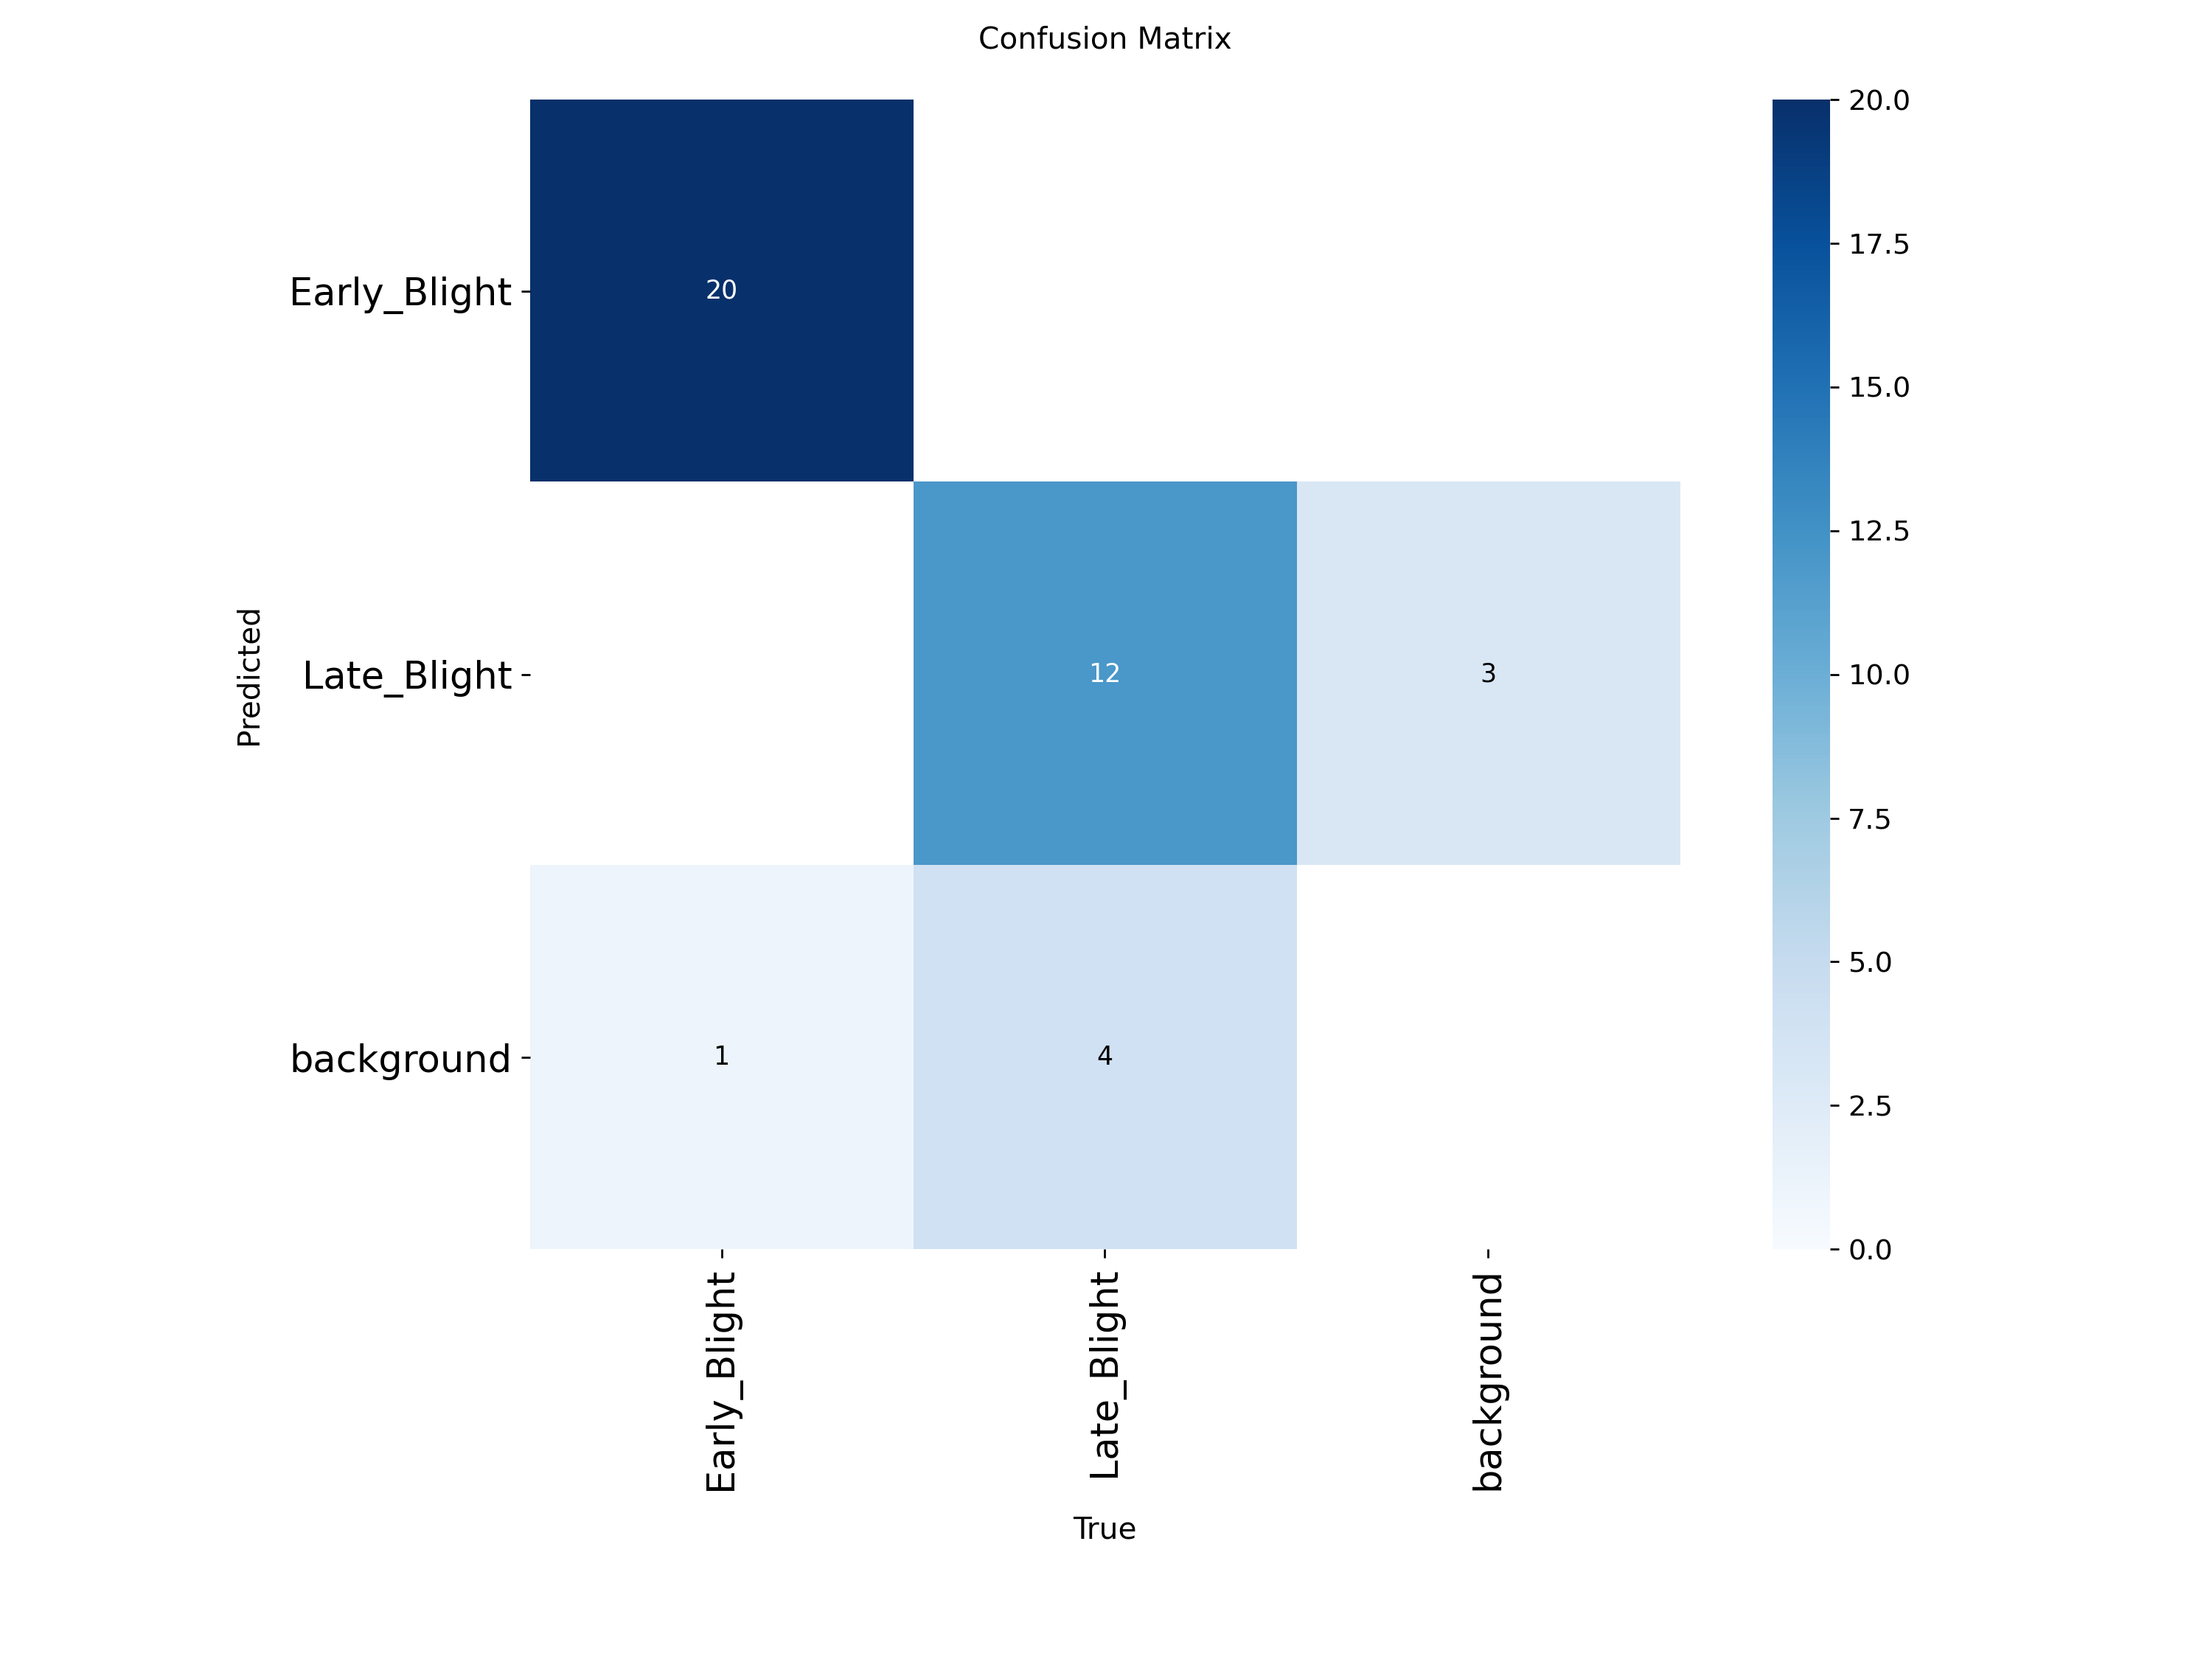

Evaluation plots saved to Drive!


In [8]:
from IPython.display import Image as IPImage, display
import shutil

eval_dir = f'{PROJECT}/{RUN_NAME}_test'
for fname, label in [('confusion_matrix.png', 'Confusion Matrix'),
                      ('PR_curve.png', 'PR Curve'),
                      ('F1_curve.png', 'F1 Curve')]:
    p = os.path.join(eval_dir, fname)
    if os.path.exists(p):
        print(f'{label}:')
        display(IPImage(p))
        shutil.copy(p, os.path.join(SAVE_DIR, f'yolov8n_benchmark_{fname}'))
print('Evaluation plots saved to Drive!')


## Step 11: Inference Speed

In [9]:
dummy_img = np.random.randint(0, 255, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
dummy_path = '/tmp/dummy.jpg'
Image.fromarray(dummy_img).save(dummy_path)

for _ in range(10):
    best_model.predict(dummy_path, verbose=False, device=DEVICE)

N = 100
t0 = time.time()
for _ in range(N):
    best_model.predict(dummy_path, verbose=False, device=DEVICE)
elapsed_ms = (time.time() - t0) / N * 1000

model_mb     = os.path.getsize(BEST_WEIGHTS) / (1024 * 1024)
total_params = sum(p.numel() for p in best_model.model.parameters())

print('=' * 50)
print('INFERENCE METRICS (Thesis Table)')
print('=' * 50)
print(f'Inference Time: {elapsed_ms:.2f} ms/image')
print(f'FPS:            {1000/elapsed_ms:.1f}')
print(f'Model Size:     {model_mb:.2f} MB')
print(f'Parameters:     {total_params:,}')


INFERENCE METRICS (Thesis Table)
Inference Time: 9.84 ms/image
FPS:            101.6
Model Size:     5.93 MB
Parameters:     3,006,038


## Step 12: Visualize Predictions

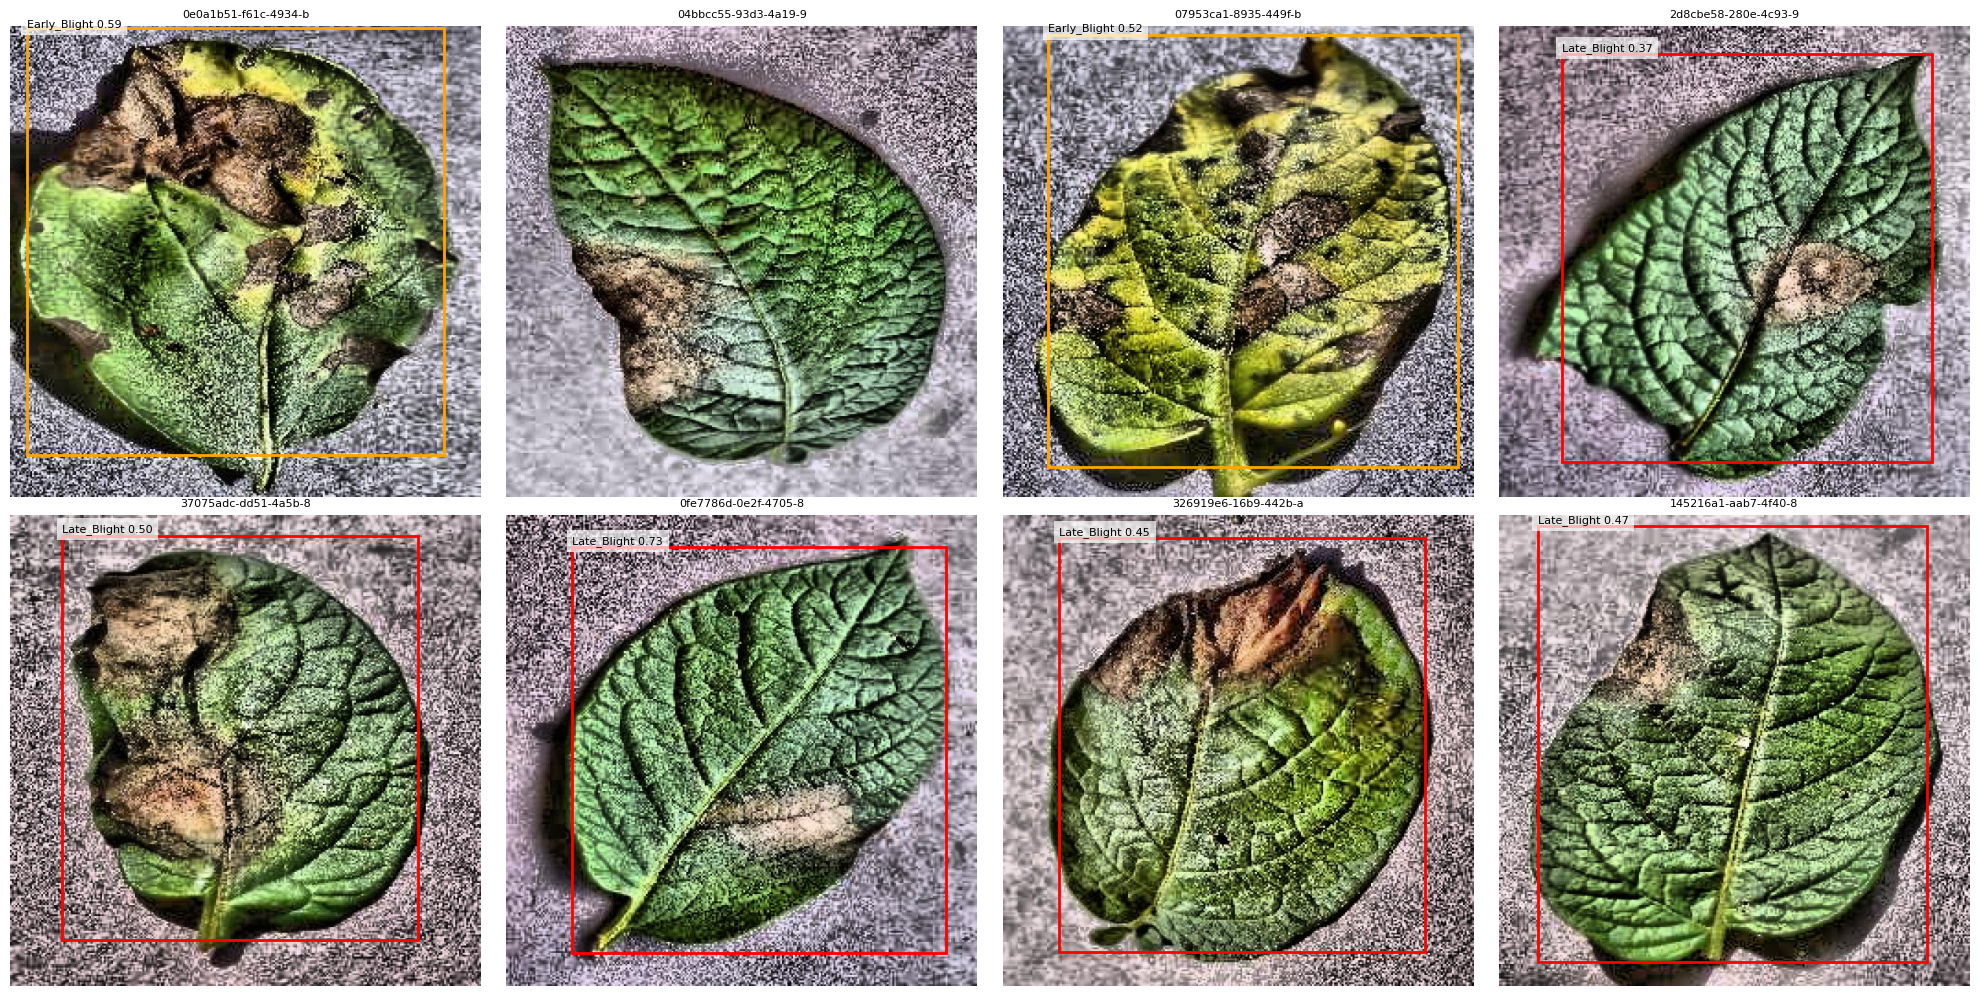

Prediction visualization saved!


In [10]:
TEST_IMG_DIR = '/content/dataset/test/images'
test_images  = list(Path(TEST_IMG_DIR).glob('*.jpg'))[:8]
if not test_images:
    test_images = list(Path(TEST_IMG_DIR).glob('*.png'))[:8]

preds = best_model.predict(
    source  = [str(p) for p in test_images],
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = DEVICE,
    verbose = False,
)

COLORS      = {0: 'orange', 1: 'red'}
CLASS_NAMES = {0: 'Early_Blight', 1: 'Late_Blight'}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (result, img_path) in enumerate(zip(preds, test_images)):
    img = np.array(Image.open(img_path).convert('RGB'))
    ax  = axes.flatten()[i]
    ax.imshow(img); ax.axis('off')
    ax.set_title(img_path.name[:20], fontsize=8)
    if result.boxes is not None:
        for box, lbl, sc in zip(result.boxes.xyxy.cpu().numpy(),
                                  result.boxes.cls.cpu().numpy().astype(int),
                                  result.boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2,
                                     edgecolor=COLORS.get(lbl, 'blue'),
                                     facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, max(y1-5, 0), f'{CLASS_NAMES.get(lbl, lbl)} {sc:.2f}',
                    fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'yolov8n_benchmark_predictions.png'), dpi=150)
plt.show()
print('Prediction visualization saved!')


## Summary
This prints the final benchmark table. Use this lighter YOLOv8n result as the below-87 comparison model against the stronger model.


In [11]:
print('=' * 55)
print('  YOLOv8 BENCHMARK RESULTS SUMMARY')
print('=' * 55)
print(f'  Model:          YOLOv8n (pretrained COCO)')
print(f'  Input Size:     {IMG_SIZE}x{IMG_SIZE}')
print(f'  Epochs:         {EPOCHS}')
print(f'  mAP@0.5:        {eval_results.box.map50:.4f}')
print(f'  mAP@0.5:0.95:   {eval_results.box.map:.4f}')
print(f'  Precision:      {precision:.4f}')
print(f'  Recall:         {recall:.4f}')
print(f'  F1 Score:       {f1:.4f}')
print(f'  Inference Time: {elapsed_ms:.2f} ms/image')
print(f'  FPS:            {1000/elapsed_ms:.1f}')
print(f'  Model Size:     {model_mb:.2f} MB')
print(f'  Parameters:     {total_params:,}')
print('=' * 55)

if eval_results.box.map50 < 0.87:
    print('Final note: This is suitable as the below-87 benchmark model.')
else:
    print('Final note: Still above 0.87. Change EPOCHS to 15 or IMG_SIZE to 416 and rerun.')


  YOLOv8 BENCHMARK RESULTS SUMMARY
  Model:          YOLOv8n (pretrained COCO)
  Input Size:     416x416
  Epochs:         15
  mAP@0.5:        0.8071
  mAP@0.5:0.95:   0.4645
  Precision:      0.9000
  Recall:         0.8512
  F1 Score:       0.8749
  Inference Time: 9.84 ms/image
  FPS:            101.6
  Model Size:     5.93 MB
  Parameters:     3,006,038
Final note: This is suitable as the below-87 benchmark model.
